<a href="https://colab.research.google.com/github/HassenElmir/AI_Diamond_Project/blob/main/AI_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np

print("🚀 Starting Dataset Preparation...")

# -----------------------------
# 1️⃣ Load dataset
# -----------------------------
df = pd.read_csv("diamonds.csv")
print(f"✅ Original dataset shape: {df.shape}")

# -----------------------------
# 2️⃣ Check missing values
# -----------------------------
print("\n🔍 Missing values before cleaning:")
print(df.isnull().sum())

# -----------------------------
# 3️⃣ Handle missing values
# -----------------------------
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = ["cut", "color", "clarity"]
for col in categorical_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\n✅ Missing values after handling:")
print(df.isnull().sum())

# -----------------------------
# 4️⃣ Remove duplicate rows
# -----------------------------
duplicates = df.duplicated().sum()
print(f"\n🔁 Number of duplicate rows: {duplicates}")

df = df.drop_duplicates()
print(f"✅ Dataset shape after removing duplicates: {df.shape}")

# -----------------------------
# 5️⃣ Handle invalid values
# -----------------------------
print("\n⚠️ Checking invalid values...")

# Remove rows where dimensions are zero or negative
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

# Remove negative prices or carat
df = df[(df['price'] > 0) & (df['carat'] > 0)]

print(f"✅ Dataset shape after removing invalid values: {df.shape}")

# -----------------------------
# 6️⃣ Handle outliers (optional but recommended)
# -----------------------------
print("\n📊 Removing extreme outliers...")

for col in ["carat", "price"]:
    q_low = df[col].quantile(0.01)
    q_high = df[col].quantile(0.99)
    df = df[(df[col] >= q_low) & (df[col] <= q_high)]

print(f"✅ Dataset shape after outlier removal: {df.shape}")

# -----------------------------
# 7️⃣ Final check
# -----------------------------
print("\n📋 Final dataset info:")
print(df.info())

print("\n📊 Final dataset summary:")
print(df.describe())

# -----------------------------
# 8️⃣ Save cleaned dataset
# -----------------------------
df.to_csv("diamonds_cleaned.csv", index=False)
print("\n💾 Cleaned dataset saved as 'diamonds_cleaned.csv'")

print("🎉 Dataset preparation completed!")

🚀 Starting Dataset Preparation...
✅ Original dataset shape: (53940, 10)

🔍 Missing values before cleaning:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

✅ Missing values after handling:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

🔁 Number of duplicate rows: 146
✅ Dataset shape after removing duplicates: (53794, 10)

⚠️ Checking invalid values...
✅ Dataset shape after removing invalid values: (53775, 10)

📊 Removing extreme outliers...


/tmp/ipykernel_2160/396393963.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


✅ Dataset shape after outlier removal: (51864, 10)

📋 Final dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 51864 entries, 60 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    51864 non-null  float64
 1   cut      51864 non-null  object 
 2   color    51864 non-null  object 
 3   clarity  51864 non-null  object 
 4   depth    51864 non-null  float64
 5   table    51864 non-null  float64
 6   price    51864 non-null  int64  
 7   x        51864 non-null  float64
 8   y        51864 non-null  float64
 9   z        51864 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.4+ MB
None

📊 Final dataset summary:
              carat         depth         table         price             x  \
count  51864.000000  51864.000000  51864.000000  51864.000000  51864.000000   
mean       0.778170     61.749240     57.444798   3729.519667      5.705681   
std        0.431475      1.425049  

**Feature Engineering**

In [2]:
import pandas as pd
import numpy as np

# -----------------------------
# Load cleaned diamonds dataset
# -----------------------------
df = pd.read_csv("diamonds_cleaned.csv")

# -----------------------------
# 1️⃣ Ordinal Encoding for Categorical Features
# -----------------------------
cut_map = {"Fair": 0, "Good": 1, "Very Good": 2, "Premium": 3, "Ideal": 4}
color_map = {"J": 0, "I": 1, "H": 2, "G": 3, "F": 4, "E": 5, "D": 6}
clarity_map = {"I1": 0, "SI2": 1, "SI1": 2,
               "VS2": 3, "VS1": 4,
               "VVS2": 5, "VVS1": 6, "IF": 7}

df["cut"] = df["cut"].map(cut_map)
df["color"] = df["color"].map(color_map)
df["clarity"] = df["clarity"].map(clarity_map)

# -----------------------------
# 2️⃣ Numeric Feature Engineering
# -----------------------------
# Remove invalid dimensions
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]

# Replace any infinite or NaN values
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# -----------------------------
# 3️⃣ Target Variable
# -----------------------------
# Split price into 3 balanced classes
df["price_class"] = pd.qcut(df["price"], q=3, labels=[0, 1, 2])

# -----------------------------
# 4️⃣ Select Features and Target
# -----------------------------
features = ["carat","cut","color","clarity","depth","table","x","y","z",
            ]
X = df[features]
y = df["price_class"]

print("Feature engineering completed.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Feature engineering completed.
Features shape: (51864, 9)
Target shape: (51864,)


**Target Creation and Data Preparation**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming df has been preprocessed & feature engineered

# -----------------------------
# 1️⃣ Price Categorization using quantiles
# -----------------------------
df["price_class"] = pd.qcut(df["price"], q=3, labels=[0, 1, 2])

# Verify class balance
print(df["price_class"].value_counts())

# -----------------------------
# 2️⃣ Feature / Target Split
# -----------------------------
features = ["carat","cut","color","clarity","depth","table","x","y","z"]
X = df[features]
y = df["price_class"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# -----------------------------
# 3️⃣ Train / Validation / Test Split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nSplit sizes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


price_class
0    17294
2    17288
1    17282
Name: count, dtype: int64
Features (X) shape: (51864, 9)
Target (y) shape: (51864,)

Split sizes:
Train: (41491, 9)
Validation: (5186, 9)
Test: (5187, 9)


**Try to generate another dataset (Dataset 2)**

In [ ]:
import pandas as pd
import numpy as np
import time
from ctgan import CTGAN

print("🚀 Starting Improved Synthetic Data Pipeline...")

# -----------------------------
# 1️⃣ Load dataset
# -----------------------------
start_time = time.time()
print("📂 Loading dataset...")
df = pd.read_csv("diamonds_cleaned.csv")
print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# -----------------------------
# 2️⃣ Define categorical columns
# -----------------------------
categorical_columns = ["cut", "color", "clarity"]

for col in categorical_columns:
    df[col] = df[col].astype(str)

# -----------------------------
# 3️⃣ Feature Engineering
# -----------------------------
print("🧠 Adding engineered features...")

df['volume'] = df['x'] * df['y'] * df['z']

# Avoid division by zero
df['ratio_xy'] = df['x'] / df['y'].replace(0, 0.001)
df['ratio_xz'] = df['x'] / df['z'].replace(0, 0.001)
df['ratio_yz'] = df['y'] / df['z'].replace(0, 0.001)

# -----------------------------
# 4️⃣ Data Cleaning
# -----------------------------
print("🧹 Cleaning data...")

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
df[numeric_cols] = df[numeric_cols].fillna(0)

# -----------------------------
# 5️⃣ Initialize CTGAN (FIXED)
# -----------------------------
print("🧠 Initializing CTGAN model...")

ctgan = CTGAN(
    epochs=600,        # high-quality training
    batch_size=500,    # ✅ must be divisible by pac=10
    verbose=True
)

# -----------------------------
# 6️⃣ Train model
# -----------------------------
print("⚙️ Training CTGAN... ⏳")

train_start = time.time()
ctgan.fit(df, categorical_columns)
train_end = time.time()

print(f"✅ Training completed in {train_end - train_start:.2f} seconds")

# -----------------------------
# 7️⃣ Save trained model
# -----------------------------
ctgan.save("ctgan_diamonds.pkl")
print("💾 CTGAN model saved as 'ctgan_diamonds.pkl'")

# -----------------------------
# 8️⃣ Generate synthetic data
# -----------------------------
print("🎲 Generating synthetic data...")

gen_start = time.time()
synthetic_data = ctgan.sample(8000)   # generate extra data
gen_end = time.time()

print(f"✅ Generated {len(synthetic_data)} rows in {gen_end - gen_start:.2f} seconds")

# -----------------------------
# 9️⃣ Post-processing (VERY IMPORTANT)
# -----------------------------
print("🧹 Cleaning synthetic data...")

# Remove invalid values
for col in ["carat", "depth", "table", "price", "x", "y", "z"]:
    synthetic_data = synthetic_data[synthetic_data[col] > 0]

# Remove extreme outliers
for col in ["carat", "price"]:
    q_low = synthetic_data[col].quantile(0.01)
    q_high = synthetic_data[col].quantile(0.99)
    synthetic_data = synthetic_data[
        (synthetic_data[col] >= q_low) &
        (synthetic_data[col] <= q_high)
    ]

print(f"✅ Cleaned dataset size: {len(synthetic_data)}")

# -----------------------------
# 🔟 Save synthetic dataset
# -----------------------------
print("💾 Saving synthetic dataset...")
synthetic_data.to_csv("synthetic_diamonds.csv", index=False)
print("✅ File saved as 'synthetic_diamonds.csv'")

# -----------------------------
# 1️⃣1️⃣ Total time
# -----------------------------
end_time = time.time()
print(f"🏁 Total execution time: {end_time - start_time:.2f} seconds")

print("🎉 Pipeline completed successfully!")

**Feature Scaling**

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training set and transform
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

**Dimensionality Reduction (PCA)**

Explained variance (2 components): 0.6263528573195523


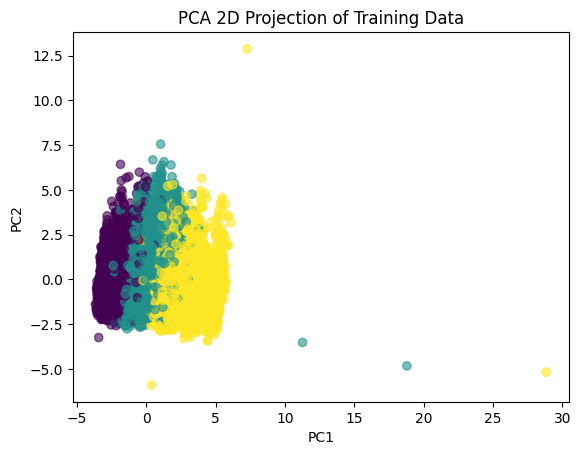

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA on scaled training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Explained variance
explained_variance = sum(pca.explained_variance_ratio_)
print("Explained variance (2 components):", explained_variance)

# Optional: visualize 2D projection
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection of Training Data")
plt.show()

**Training During Optuna HyperParameter Optimization**

In [6]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.8 MB/s eta 0:00:00


In [7]:
# =========================
# OPTUNA RANDOM FOREST HYPERPARAMETER TUNING + VISUALIZATION
# =========================

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import optuna.visualization as opt_viz

# -------------------------
# Objective function
# -------------------------
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train)           # Training on scaled training set
    val_pred = model.predict(X_val_scaled)       # Validate on scaled validation set
    return accuracy_score(y_val, val_pred)

# -------------------------
# Create and run Optuna study
# -------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

# -------------------------
# Print best hyperparameters
# -------------------------
best_params = study.best_trial.params
print("Best Hyperparameters:", best_params)

# =========================
# VISUALIZATIONS
# =========================

# 1️⃣ Optimization History
fig1 = opt_viz.plot_optimization_history(study)
fig1.show()  # Track objective value (accuracy) across trials

# 2️⃣ Hyperparameter Importance
fig2 = opt_viz.plot_param_importances(study)
fig2.show()  # See which hyperparameters affect performance the most

# 3️⃣ Parallel Coordinate Plot
fig3 = opt_viz.plot_parallel_coordinate(study)
fig3.show()  # Visualize relationships between hyperparameters and accuracy

[I 2026-03-29 15:38:23,941] A new study created in memory with name: no-name-216d37d3-0e75-4dd7-8e36-ca42f410ab41
[I 2026-03-29 15:38:26,393] Trial 0 finished with value: 0.9616274585422291 and parameters: {'n_estimators': 78, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.9616274585422291.
[I 2026-03-29 15:38:31,340] Trial 1 finished with value: 0.9519861164674123 and parameters: {'n_estimators': 61, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 0 with value: 0.9616274585422291.
[I 2026-03-29 15:38:57,591] Trial 2 finished with value: 0.9514076359429232 and parameters: {'n_estimators': 198, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.9616274585422291.
[I 2026-03-29 15:39:06,632] Trial 3 finished with value: 0.9612418048592364 and parameters: {'n_estimators': 122, 'max_depth': 12, 'min_sampl

Best Hyperparameters: {'n_estimators': 78, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2'}


**Training the Best Model**

Validation Accuracy: 0.9618
Test Accuracy: 0.9557


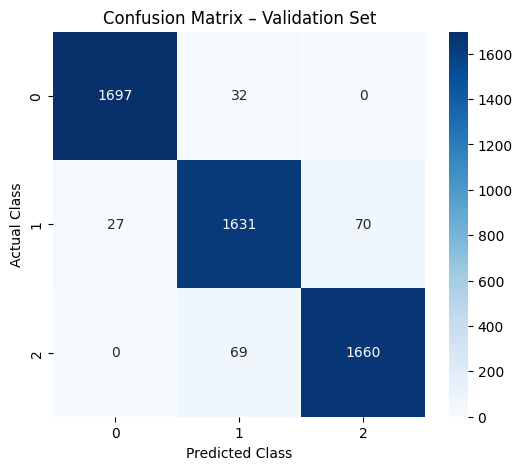

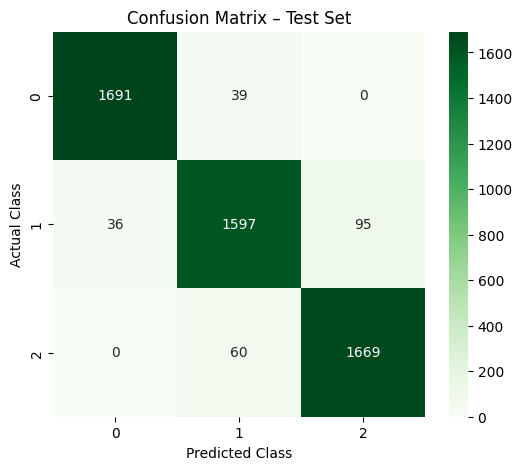

In [ ]:
# =========================
# FINAL RANDOM FOREST TRAINING
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Initialize Random Forest with best parameters
# -------------------------
final_model = RandomForestClassifier(
    n_estimators=149,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

# -------------------------
# Train model on scaled training set
# -------------------------
final_model.fit(X_train_scaled, y_train)

# -------------------------
# Predict on validation and test sets
# -------------------------
y_val_pred = final_model.predict(X_val_scaled)
y_test_pred = final_model.predict(X_test_scaled)

# -------------------------
# Accuracy Scores
# -------------------------
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# =========================
# CONFUSION MATRIX - VALIDATION SET
# =========================
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix – Validation Set")
plt.show()

# =========================
# CONFUSION MATRIX - TEST SET
# =========================
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix – Test Set")
plt.show()

**Evaluating on Synthetic Data**

In [ ]:
# =========================
# CROSS-VALIDATION ON SYNTHETIC DATA USING FIXED RANDOM FOREST
# =========================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

# -------------------------
# Load synthetic data
# -------------------------
df_syn = pd.read_csv("synthetic_diamonds.csv")

# Encode categorical features
cut_map = {"Fair": 0, "Good": 1, "Very Good": 2, "Premium": 3, "Ideal": 4}
color_map = {"J": 0, "I": 1, "H": 2, "G": 3, "F": 4, "E": 5, "D": 6}
clarity_map = {"I1": 0, "SI2": 1, "SI1": 2, "VS2": 3, "VS1": 4, "VVS2": 5, "VVS1": 6, "IF": 7}

df_syn["cut"] = df_syn["cut"].map(cut_map)
df_syn["color"] = df_syn["color"].map(color_map)
df_syn["clarity"] = df_syn["clarity"].map(clarity_map)

# Feature engineering
df_syn = df_syn[(df_syn["x"] > 0) & (df_syn["y"] > 0) & (df_syn["z"] > 0)]
df_syn = df_syn.replace([np.inf, -np.inf], np.nan).dropna()

# Balanced target classes
df_syn["price_class"] = pd.qcut(df_syn["price"], q=3, labels=[0,1,2])

features = ["carat","cut","color","clarity","depth","table","x","y","z"]
X_syn = df_syn[features]
y_syn = df_syn["price_class"]

# Scale using previously fitted scaler
X_syn_scaled = scaler.transform(X_syn)

# -------------------------
# Initialize Random Forest with fixed best parameters
# -------------------------
rf_fixed = RandomForestClassifier(
    n_estimators=149,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

# -------------------------
# 5-fold Cross-validation
# -------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_fixed, X_syn_scaled, y_syn, cv=kf, scoring="accuracy")

# -------------------------
# Results
# -------------------------
print("Cross-validation accuracy per fold:", cv_scores)
print("Mean accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation accuracy per fold: [0.8451529  0.85296031 0.83333333 0.84179688 0.84440104]
Mean accuracy: 0.843528891509434
Standard deviation: 0.006313462121927308
